### 1. Импорты

In [36]:
import random
import matplotlib.pyplot as plt

### 2. Расчет параллельного соединения

In [76]:
def serial_connection(resistors:list):
    return sum(resistors)


def parallel_connection(resistors:list):
    return 1/sum([1/i for i in resistors])

def generate_resistors(num_resistors:int, sigma:float, offset:int):
    resistors = []
    for i in range(num_resistors):
        erlang6 = (sum([random.random() for _ in range(6)])-3)*2**0.5
        resistors.append(sigma*erlang6 +offset)
    return resistors

LEN_DICT = 500000
dataset_serial = dict()
for i in range(LEN_DICT):
    # Сопротивление цепи
    circuit_resistance = serial_connection(generate_resistors(num_resistors=2, sigma=1, offset=10))
    res = round(circuit_resistance,1)
    dataset_serial[res] = 1 if res not in dataset_serial else dataset_serial[res] + 1
print(dataset_serial)

dataset_parallel = dict()
for i in range(LEN_DICT):
    circuit_resistance = parallel_connection(generate_resistors(num_resistors=2, sigma=4, offset=40))
    res = round(circuit_resistance,1)
    dataset_parallel[res] = 1 if res not in dataset_parallel else dataset_parallel[res] + 1


dataset_many_serial = dict()
for i in range(LEN_DICT):
    circuit_resistance = serial_connection(generate_resistors(num_resistors=20, sigma=2/20, offset=20/20))
    res = round(circuit_resistance,1)
    dataset_many_serial[res] = 1 if res not in dataset_many_serial else dataset_many_serial[res] + 1

dataset_many_parallel = dict()
for i in range(LEN_DICT):
    circuit_resistance = parallel_connection(generate_resistors(num_resistors=20, sigma=2*20, offset=20*20))
    res = round(circuit_resistance,1)
    dataset_many_parallel[res] = 1 if res not in dataset_many_parallel else dataset_many_parallel[res] + 1

{18.9: 10415, 19.9: 13833, 21.0: 11089, 21.2: 9787, 19.8: 13808, 23.3: 881, 20.4: 13303, 19.6: 13345, 19.0: 11038, 20.8: 11955, 19.4: 13023, 18.1: 5883, 20.1: 14163, 18.0: 5377, 21.1: 10531, 19.2: 12012, 18.5: 8275, 18.6: 8614, 20.3: 13815, 21.5: 8130, 21.9: 5738, 20.2: 13803, 23.9: 280, 17.7: 3912, 20.5: 13012, 17.9: 4696, 22.0: 5239, 19.7: 13789, 22.3: 3779, 17.5: 3071, 18.4: 7627, 18.2: 6465, 19.3: 12390, 21.3: 9377, 24.0: 247, 22.1: 4734, 22.2: 4262, 17.6: 3380, 22.9: 1711, 21.6: 7533, 19.5: 12967, 18.7: 9159, 16.7: 927, 21.8: 6540, 18.8: 9766, 23.2: 1101, 20.6: 12761, 21.7: 6959, 23.1: 1277, 17.8: 4351, 18.3: 6827, 20.0: 13901, 19.1: 11359, 22.4: 3432, 20.7: 12267, 25.7: 2, 22.8: 2011, 20.9: 11430, 22.6: 2701, 21.4: 8665, 17.0: 1492, 22.7: 2383, 22.5: 3028, 16.8: 1105, 17.3: 2324, 17.2: 2022, 17.1: 1721, 23.4: 752, 16.6: 781, 24.3: 111, 17.4: 2742, 23.7: 455, 16.5: 648, 23.0: 1479, 16.9: 1294, 23.5: 622, 16.3: 462, 16.2: 344, 16.4: 548, 15.9: 198, 24.2: 157, 16.1: 307, 15.8: 142, 

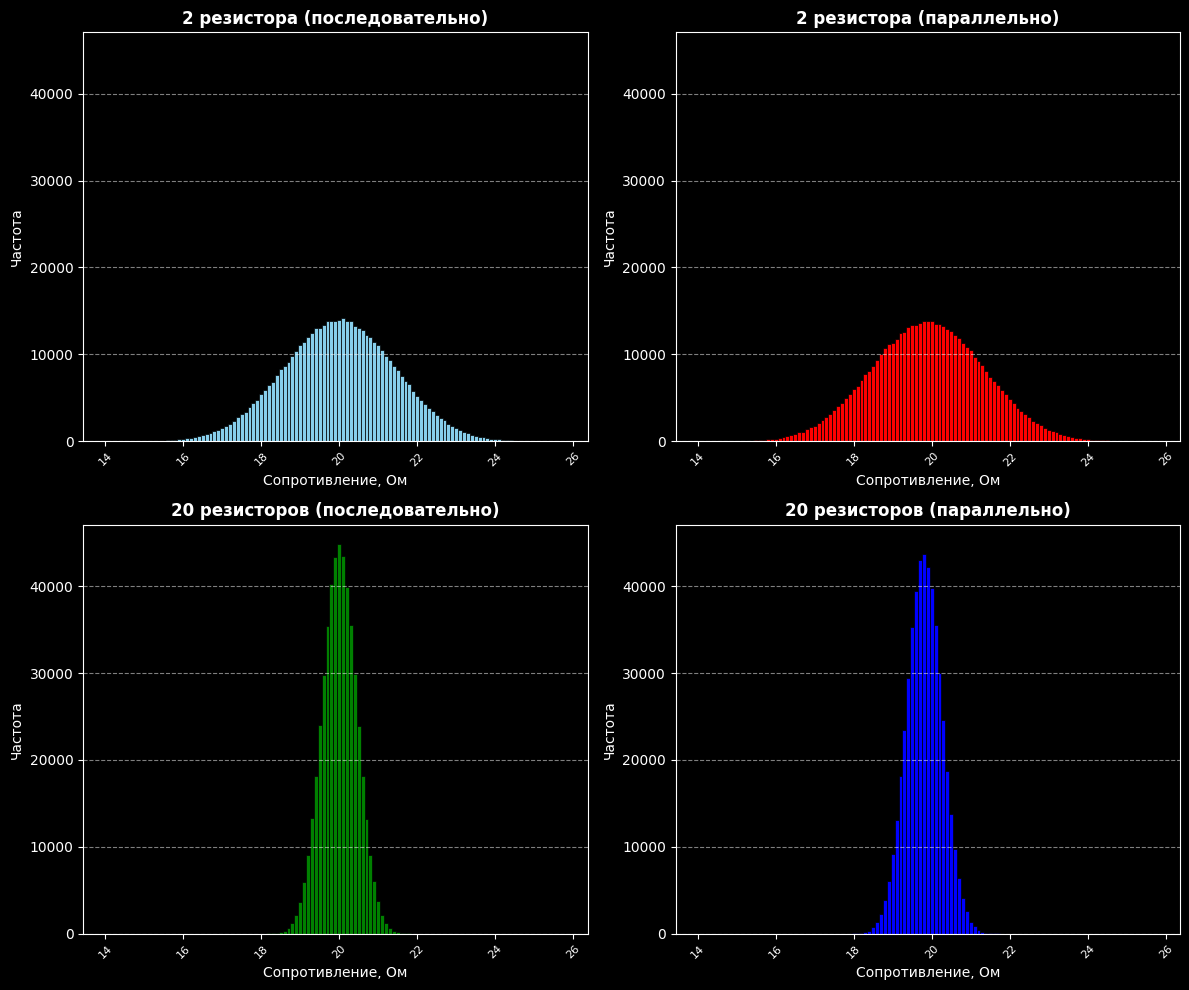

In [77]:
import matplotlib.pyplot as plt

datasets = [dataset_serial, dataset_parallel, dataset_many_serial, dataset_many_parallel]
titles = ['2 резистора (последовательно)', '2 резистора (параллельно)',
          '20 резисторов (последовательно)', '20 резисторов (параллельно)']
colors = ['skyblue', 'red', 'green', 'blue']

# 🔍 Находим глобальные границы для единого масштаба
all_x, all_y = [], []
for data in datasets:
    if data:  # пропускаем пустые словари
        all_x.extend(data.keys())
        all_y.extend(data.values())

x_min, x_max = min(all_x), max(all_x)
y_max = max(all_y)

# 🔧 Отступы по краям (2-5%)
x_margin = (x_max - x_min) * 0.03
y_margin = y_max * 0.05

# 🎯 ФИКСИРОВАННАЯ ширина столбца (под вашу точность 0.1)
# Если ключи идут с шагом 0.1, то width=0.08 даст небольшой зазор между столбцами
BAR_WIDTH = 0.1

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, data, title, color in zip(axes.flat, datasets, titles, colors):
    if not data:
        continue

    # Сортируем по ключам для корректного порядка на оси X
    sorted_items = sorted(data.items())
    categories = [k for k, _ in sorted_items]
    values = [v for _, v in sorted_items]

    # 🔑 Ключевой момент: bar() с маленькой фиксированной шириной
    ax.bar(categories, values, width=BAR_WIDTH, color=color, edgecolor='black', linewidth=0.5)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Сопротивление, Ом')
    ax.set_ylabel('Частота')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # 🔒 Единый масштаб для всех графиков
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    ax.set_ylim(0, y_max + y_margin)

    # 💡 Опционально: повернуть подписи, если их много
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)

plt.tight_layout()
plt.show()